## Imbalanced Datasets

In [27]:
# Step 1: Import Required Lib
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [28]:
# Step 2: Load the Dataset
df = pd.read_csv("C:\\Users\\vaish\\OneDrive\\Documents\\DATA SCIENCE COURSE\\ML\\ML_TASK\\Imbalance_Problem\\decision_tree_dataset.csv")

In [29]:
# Step 3: Check the Dataset
df.head()

,age,income,credit_score,city,gender,purchases,loan_amount,approved
0,41,16832.970365,646.435852,Hyderabad,Female,2,NaN,0
1,61,24958.920783,772.103370,Bangalore,Female,2,109037.369348,0
2,29,26661.565307,742.165011,Bangalore,Male,3,140981.063625,0
3,40,76918.367953,789.568381,Mumbai,Female,2,265765.286243,0
4,18,33446.160242,650.679984,Delhi,Male,4,187481.809910,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        947 non-null    float64
 2   credit_score  946 non-null    float64
 3   city          1050 non-null   object 
 4   gender        1050 non-null   object 
 5   purchases     1050 non-null   int64  
 6   loan_amount   947 non-null    float64
 7   approved      1050 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 65.8+ KB


In [31]:
# check the missing values
df.isnull().sum()

age               0
income          103
credit_score    104
city              0
gender            0
purchases         0
loan_amount     103
approved          0
dtype: int64

In [32]:
df.describe()

,age,income,credit_score,purchases,loan_amount,approved
count,1050.000000,947.000000,946.000000,1050.000000,9.470000e+02,1050.000000
mean,43.737143,55807.648029,651.605495,2.934286,2.086066e+05,0.303810
std,15.021797,40021.647680,100.166162,1.603281,1.270517e+05,0.460121
min,18.000000,6556.169327,348.048784,0.000000,-5.768131e+04,0.000000
25%,31.000000,40886.541936,584.998140,2.000000,1.378232e+05,0.000000
50%,44.000000,50967.116222,650.052796,3.000000,1.971923e+05,0.000000
75%,56.000000,60643.014837,718.563117,4.000000,2.598691e+05,1.000000
max,69.000000,445126.233564,969.310757,9.000000,1.233105e+06,1.000000


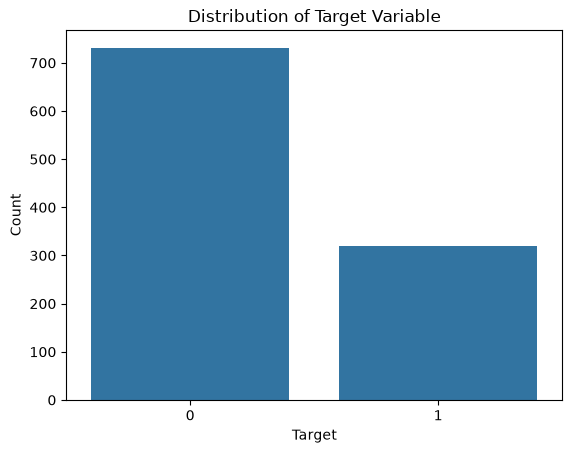

In [33]:
# Step 4: Data Visualization

sns.countplot(x='approved', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

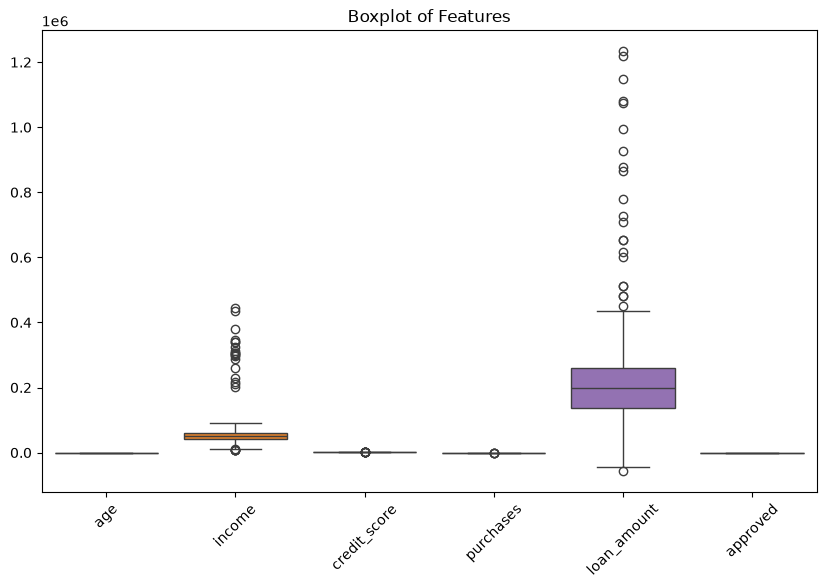

In [34]:
# make boxplot to check the outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of Features')
plt.xticks(rotation=45)
plt.show()

In [35]:
# handled the missing values 

# find the all columns which have missing values

income_median = round(df['income'].median(), 2)
credit_score_median = round(df['credit_score'].median(), 2)
loan_amount_median = round(df['loan_amount'].median(), 2)

# fill the missing values with median values
df['income'].fillna(income_median, inplace=True)
df['credit_score'].fillna(credit_score_median, inplace=True)
df['loan_amount'].fillna(loan_amount_median, inplace=True)

C:\Users\vaish\AppData\Local\Temp\ipykernel_17684\3387577728.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(income_median, inplace=True)
C:\Users\vaish\AppData\Local\Temp\ipykernel_17684\3387577728.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

<Axes: ylabel='credit_score'>

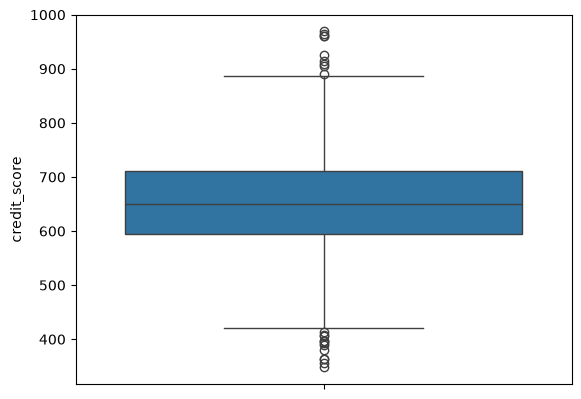

In [36]:
sns.boxplot(data=df['credit_score'])

In [37]:
#  handle the outliers using IQR method

outlier_columns = ['income', 'credit_score', 'loan_amount']

for col in outlier_columns:

    # find Quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # find IQR 
    IQR = Q3 - Q1

    # find lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # handled the outliers clipping the values to the lower and upper bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


    

In [38]:
# drop the city column as it is not useful for the model
df.drop('city', axis=1, inplace=True)

In [39]:
# replace the gender column values with 0 and 1
df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})


C:\Users\vaish\AppData\Local\Temp\ipykernel_17684\2493922993.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male': 0, 'Female': 1})


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1050 non-null   int64  
 1   income        1050 non-null   float64
 2   credit_score  1050 non-null   float64
 3   gender        1050 non-null   int64  
 4   purchases     1050 non-null   int64  
 5   loan_amount   1050 non-null   float64
 6   approved      1050 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 57.6 KB


In [41]:
# step 5: Split the dataset into features and target variable
X = df.drop('approved', axis=1)
y = df['approved']

In [42]:
y.value_counts()

approved
0    731
1    319
Name: count, dtype: int64

In [43]:
# # handled the imbalanced dataset using RandomOverSampler technique

# # 1: RadomOverSampler technique
# from imblearn.over_sampling import RandomOverSampler

# # instane of RandomOverSampler
# ros = RandomOverSampler(random_state=42)

# # fit and transform the training data
# X_resampled, y_resampled = ros.fit_resample(X, y)


In [44]:
# 2: SMOTE technique
from imblearn.over_sampling import SMOTE

# instance of SMOTE
smote = SMOTE(random_state=42)

# fit and transform the training data
X_resampled, y_resampled = smote.fit_resample(X, y)


In [45]:
y_resampled.value_counts()

approved
0    731
1    731
Name: count, dtype: int64

In [ ]:
# Step 6: Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [47]:
# step 7: model building 
from sklearn.linear_model import LogisticRegression

#instance of LogisticRegression
LR = LogisticRegression()

# train the model on X_train and y_train
model = LR.fit(X_train, y_train)

# Predict the target variable on X_test
y_pred = model.predict(X_test)

c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
# Step 8: Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# find the accuracy 
accuracy  = accuracy_score(y_test,y_pred)

# find the confustion metrics
confustion = confusion_matrix(y_test,y_pred)

# Find the classification report
report = classification_report(y_test,y_pred)



In [49]:
print("Accuracy of model:",accuracy)

Accuracy of model: 0.7030716723549488


In [50]:
print("confusion_matrix:")
print(confustion)

confusion_matrix:
[[105  56]
 [ 31 101]]


In [51]:
print("classification_report:")
print(report)

classification_report:
              precision    recall  f1-score   support

           0       0.77      0.65      0.71       161
           1       0.64      0.77      0.70       132

    accuracy                           0.70       293
   macro avg       0.71      0.71      0.70       293
weighted avg       0.71      0.70      0.70       293



# Model 2: Descision Tree


In [52]:
from sklearn.tree import DecisionTreeClassifier
# create instance
DT= DecisionTreeClassifier()

# train the model

model=DT.fit(X_train,y_train)

y_pred=model.predict(X_test)

In [53]:
# Step 8: Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# find the accuracy 
accuracy  = accuracy_score(y_test,y_pred)

# find the confustion metrics
confustion = confusion_matrix(y_test,y_pred)

# Find the classification report
report = classification_report(y_test,y_pred)

print("Accuracy of model:",accuracy)

Accuracy of model: 0.9522184300341296
